# Spark Project - Predict Baseball players with a Hall of Fame ballot appearance

## Data Preparation and EDA

### Import

In [15]:
# Imports
from pyspark.sql import SparkSession, functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.classification import (
    LogisticRegression, 
    RandomForestClassifier, 
    DecisionTreeClassifier, 
    MultilayerPerceptronClassifier, 
    GBTClassifier
)
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator, 
    BinaryClassificationEvaluator
)
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from typing import List, Dict, Any
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


### Create a Pyspark Session

In [16]:
# Spark Session Builder
spark = (
    SparkSession.builder
        .appName("LoadPlayerStats")
        .master("local[*]")                
        .config("spark.driver.host", "127.0.0.1") 
        .getOrCreate()
)

print("Spark version:", spark.version)


Spark version: 3.4.1


### Print Schema

In [17]:
# Check Schema
player_stats = spark.read.option("header", True) \
    .option("inferSchema", True) \
    .csv("player_stats.csv")

player_stats.printSchema()
player_stats.show(5)

root
 |-- player_id: string (nullable = true)
 |-- ballot_appearance: integer (nullable = true)
 |-- g: integer (nullable = true)
 |-- ab: double (nullable = true)
 |-- h: double (nullable = true)
 |-- hr: double (nullable = true)
 |-- rbi: double (nullable = true)
 |-- bb: double (nullable = true)
 |-- so: double (nullable = true)
 |-- w: integer (nullable = true)
 |-- l: integer (nullable = true)
 |-- era: double (nullable = true)
 |-- ipouts: double (nullable = true)
 |-- pit_so: integer (nullable = true)
 |-- po: double (nullable = true)
 |-- a: double (nullable = true)
 |-- e: double (nullable = true)
 |-- salary: double (nullable = true)
 |-- pos: string (nullable = true)
 |-- all_star_games: integer (nullable = true)
 |-- has_salary_info: double (nullable = true)

+---------+-----------------+---+-----+-----+---+----+----+----+---+---+----+------+------+-----+----+----+---------+---+--------------+---------------+
|player_id|ballot_appearance|  g|   ab|    h| hr| rbi|  bb|  so| 

### Function to evaluate metrics

In [18]:
# Evaluation function to get metrics
def evaluate_metrics_visual(
    predictions,
    labelCol: str = "indexedLabel",
    predictionCol: str = "prediction",
    metrics: List[str] = None,
    figsize: tuple = (10, 6),
    cmap: str = "Blues",
    verbose: bool = True
) -> Dict[str, Any]:
    """
    Compute common multiclass metrics and produce two visualizations:
      1) horizontal bar chart of metrics
      2) confusion matrix heatmap

    Returns a dict with keys:
      - scores: dict metric -> float (includes macroF1 for imbalanced data)
      - confusion_matrix: numpy array (counts)
      - labels: list of label values in matrix order
      - confusion_df: pandas DataFrame of the matrix
    """
    if metrics is None:
        metrics = ["accuracy", "f1", "weightedPrecision", "weightedRecall"]

    # 1) Compute PySpark metrics
    scores: Dict[str, float] = {}
    for m in metrics:
        ev = MulticlassClassificationEvaluator(metricName=m, labelCol=labelCol, predictionCol=predictionCol)
        try:
            val = float(ev.evaluate(predictions))
        except Exception:
            val = float("nan")
        scores[m] = val
        if verbose:
            print(f"{m}: {val:.6f}")

    # 2) Build confusion matrix
    grouped = predictions.groupBy(labelCol, predictionCol).count().collect()
    if not grouped:
        if verbose:
            print("No rows to build confusion matrix.")
        return {"scores": scores, "confusion_matrix": None, "labels": [], "confusion_df": None}

    labels = sorted({r[labelCol] for r in grouped} | {r[predictionCol] for r in grouped})
    idx = {lab: i for i, lab in enumerate(labels)}
    n = len(labels)
    mat = np.zeros((n, n), dtype=int)
    for r in grouped:
        i = idx[r[labelCol]]
        j = idx[r[predictionCol]]
        mat[i, j] = int(r["count"])

    # 3) Prepare pandas DataFrame
    confusion_df = pd.DataFrame(mat, index=labels, columns=labels)

    # 4) Calculate MACRO F1 from confusion matrix 
    # This is done, because data is imbalanced, and Macro-F1 Score is the best metric to really assess the models performance
    macro_f1 = 0.0
    if len(labels) > 0:
        per_class_f1 = []
        for i in range(n):
            tp = mat[i, i]
            fp = np.sum(mat[:, i]) - tp
            fn = np.sum(mat[i, :]) - tp
            
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            per_class_f1.append(f1)
        
        macro_f1 = np.mean(per_class_f1)
    
    scores["macroF1"] = macro_f1
    if verbose:
        print(f"macroF1: {macro_f1:.6f}")

    # 5) Plot metrics bar chart
    plt.figure(figsize=(figsize[0], 3.5))
    metric_names = list(scores.keys())
    metric_vals = [scores[k] for k in metric_names]
    sns.barplot(x=metric_vals, y=metric_names, palette="viridis")
    plt.xlim(0, 1)
    plt.xlabel("Score")
    plt.title("Multiclass Metrics (Macro F1 for Imbalanced Data)")
    for i, v in enumerate(metric_vals):
        plt.text(v + 0.01, i, f"{v:.3f}", va="center")
    plt.tight_layout()
    plt.show()

    # 6) Plot confusion matrix heatmap
    plt.figure(figsize=(figsize[0], figsize[1]))
    sns.heatmap(confusion_df, annot=True, fmt="g", cmap=cmap, cbar=True,
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {
        "scores": scores,
        "confusion_matrix": mat,
        "labels": labels,
        "confusion_df": confusion_df
    }

### Splitting dataset into train and test

In [19]:
trainingDF, testDF = player_stats.randomSplit([0.8, 0.2], seed=42)
print(f"Training: {trainingDF.count()} | Test: {testDF.count()}")

Training: 14989 | Test: 3670


### Data scaling, weighing and assembling

In [20]:
# Feature transformation of the categorical column position
pos_indexer = StringIndexer(inputCol="pos", outputCol="pos_index", handleInvalid="keep")
pos_ohe = OneHotEncoder(inputCol="pos_index", outputCol="pos_ohe", handleInvalid="keep")

# Label transformation of ballot_appearance
label_indexer = StringIndexer(inputCol="ballot_appearance", outputCol="label")

# VectorAssembler to creat vector
numeric_features = ["g", "ab", "h", "hr", "rbi", "bb", "so", "w", "l", "era", 
                    "ipouts", "pit_so", "po", "a", "e", "salary", "all_star_games", "has_salary_info"]
all_features = numeric_features + ["pos_ohe"]

vecAssembler = VectorAssembler(
    inputCols=all_features,
    outputCol="unscaled_features",
    handleInvalid="skip"
)

# StandardScaler to avoid large values (Salary) dominating
scaler = StandardScaler(
    inputCol="unscaled_features", 
    outputCol="features", 
    withStd=True, 
    withMean=True
)

# Pipeline creation
pipeline = Pipeline(stages=[pos_indexer, pos_ohe, label_indexer, vecAssembler, scaler])

# Fit pipeline on training
pipeline_model = pipeline.fit(trainingDF)

trainingVecDF = pipeline_model.transform(trainingDF)
testVecDF = pipeline_model.transform(testDF)

# Class Weighting (trying to solve the issue of an underrepresented class)
num_negatives = trainingVecDF.filter(F.col("label") == 0).count()
num_positives = trainingVecDF.filter(F.col("label") == 1).count()
balancing_ratio = num_negatives / num_positives

trainingVecDF = trainingVecDF.withColumn("classWeight", 
    F.when(F.col("label") == 1, balancing_ratio).otherwise(1.0))

# Display result
trainingVecDF.select("features", "label", "classWeight").show(5, truncate=False)
print(f"Total Rows: {trainingVecDF.count()}")
print(f"Balancing Ratio applied to positive class: {balancing_ratio:.2f}")

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+------------------+
|features                                                                                                                                                                                                                                                                                                                                                     

## Test 5 classifier models

### 1. Gradient-Boosting Model

GBT RESULTS:
accuracy: 0.965123
f1: 0.963618
weightedPrecision: 0.962891
weightedRecall: 0.965123
macroF1: 0.836170


C:\Users\rfaber\AppData\Local\Temp\ipykernel_15292\1195369403.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric_vals, y=metric_names, palette="viridis")


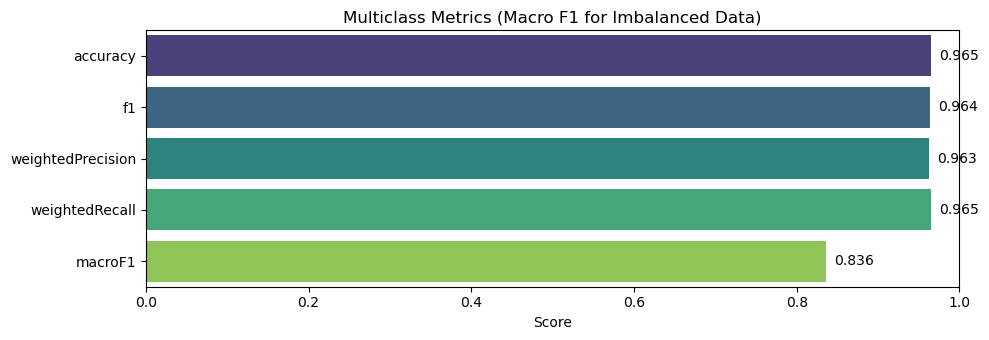

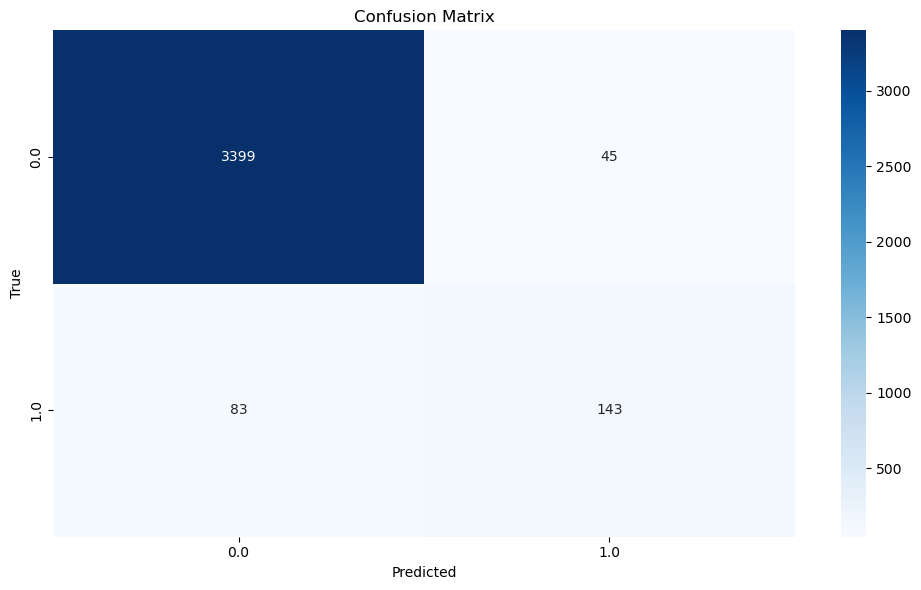

Scores: {'accuracy': 0.9651226158038148, 'f1': 0.9636176415515658, 'weightedPrecision': 0.9628910235920412, 'weightedRecall': 0.9651226158038146, 'macroF1': np.float64(0.8361700851374294)}
Labels: [0.0, 1.0]
Confusion matrix:
 [[3399   45]
 [  83  143]]


In [21]:
# Initialize the gradient-boosting classifier
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    maxIter=50,        
    maxDepth=5,        
    stepSize=0.1,      
    seed=42
)

# Fit the model
gbt_model = gbt.fit(trainingVecDF)

# Make predictions
gbt_predictions = gbt_model.transform(testVecDF)

print("GBT RESULTS:")

# Evaluation using custom function
out = evaluate_metrics_visual(gbt_predictions,
                              labelCol="label",
                              predictionCol="prediction",
                              metrics=["accuracy","f1","weightedPrecision","weightedRecall"])

# Inspect results
print("Scores:", out["scores"])
print("Labels:", out["labels"])
print("Confusion matrix:\n", out["confusion_matrix"])

### 2. Logistic regression model

accuracy: 0.965395
f1: 0.963594
weightedPrecision: 0.962920
weightedRecall: 0.965395
macroF1: 0.834821


C:\Users\rfaber\AppData\Local\Temp\ipykernel_15292\1195369403.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric_vals, y=metric_names, palette="viridis")


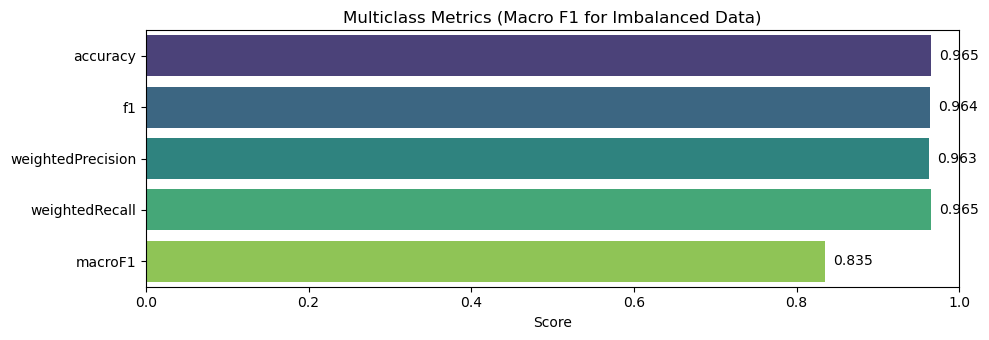

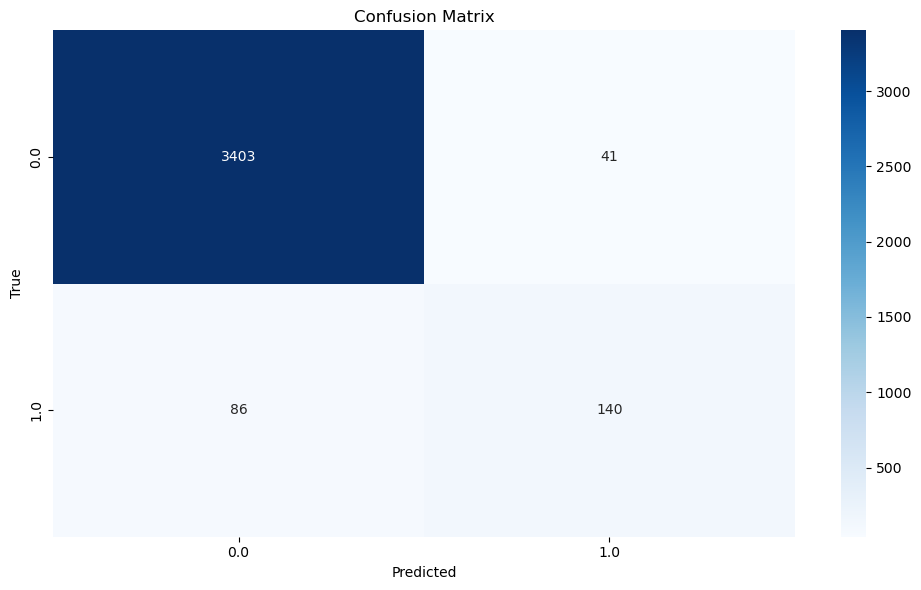

Scores: {'accuracy': 0.9653950953678474, 'f1': 0.963594352784071, 'weightedPrecision': 0.9629198447352022, 'weightedRecall': 0.9653950953678474, 'macroF1': np.float64(0.8348212497931234)}
Labels: [0.0, 1.0]
Confusion matrix:
 [[3403   41]
 [  86  140]]


In [22]:
# Train logistic regression model
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=100)

# Fit model
lr_model = lr.fit(trainingVecDF)

# Predictions
predictions = lr_model.transform(testVecDF)

# Evaluation using custom function
out = evaluate_metrics_visual(predictions,
                              labelCol="label",
                              predictionCol="prediction",
                              metrics=["accuracy","f1","weightedPrecision","weightedRecall"])

# Inspect results
print("Scores:", out["scores"])
print("Labels:", out["labels"])
print("Confusion matrix:\n", out["confusion_matrix"])


### 3. Decision-Tree Model

accuracy: 0.962125
f1: 0.960632
weightedPrecision: 0.959767
weightedRecall: 0.962125
macroF1: 0.823294


C:\Users\rfaber\AppData\Local\Temp\ipykernel_15292\1195369403.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric_vals, y=metric_names, palette="viridis")


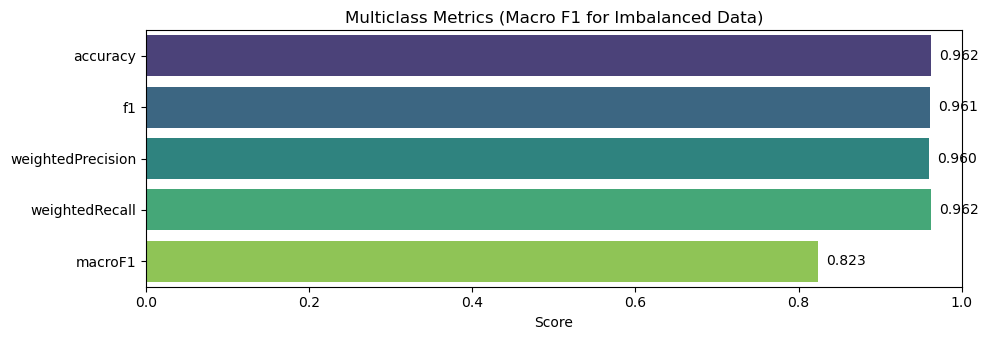

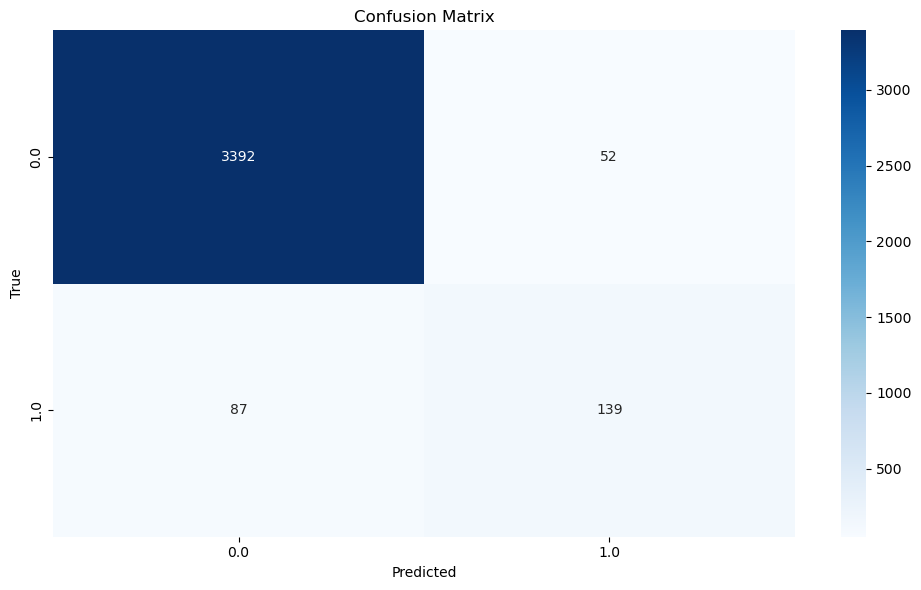

Scores: {'accuracy': 0.9621253405994551, 'f1': 0.9606316162620798, 'weightedPrecision': 0.959767426620582, 'weightedRecall': 0.962125340599455, 'macroF1': np.float64(0.8232943328999951)}
Labels: [0.0, 1.0]
Confusion matrix:
 [[3392   52]
 [  87  139]]


In [23]:
# Initialize the decision-tree classifier
dtc = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    impurity="entropy",
    maxDepth=7,
    maxBins=32,
    minInstancesPerNode=3
)

# Fit model
dt_model = dtc.fit(trainingVecDF)

# Evaluate on test set
predictions = dt_model.transform(testVecDF)

# Evaluation using custom function
out = evaluate_metrics_visual(
    predictions,
    labelCol="label",
    predictionCol="prediction",
    metrics=["accuracy","f1","weightedPrecision","weightedRecall"]
)

# Inspect results
print("Scores:", out["scores"])
print("Labels:", out["labels"])
print("Confusion matrix:\n", out["confusion_matrix"])


### 4. Random Forest

accuracy: 0.966485
f1: 0.964741
weightedPrecision: 0.964138
weightedRecall: 0.966485
macroF1: 0.840024


C:\Users\rfaber\AppData\Local\Temp\ipykernel_15292\1195369403.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric_vals, y=metric_names, palette="viridis")


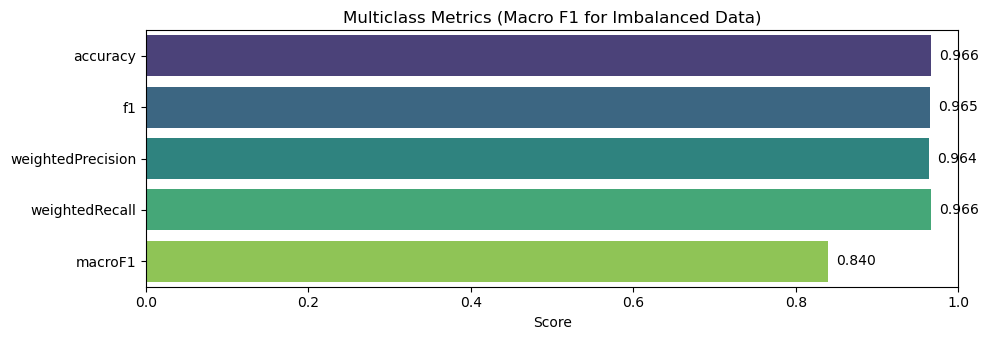

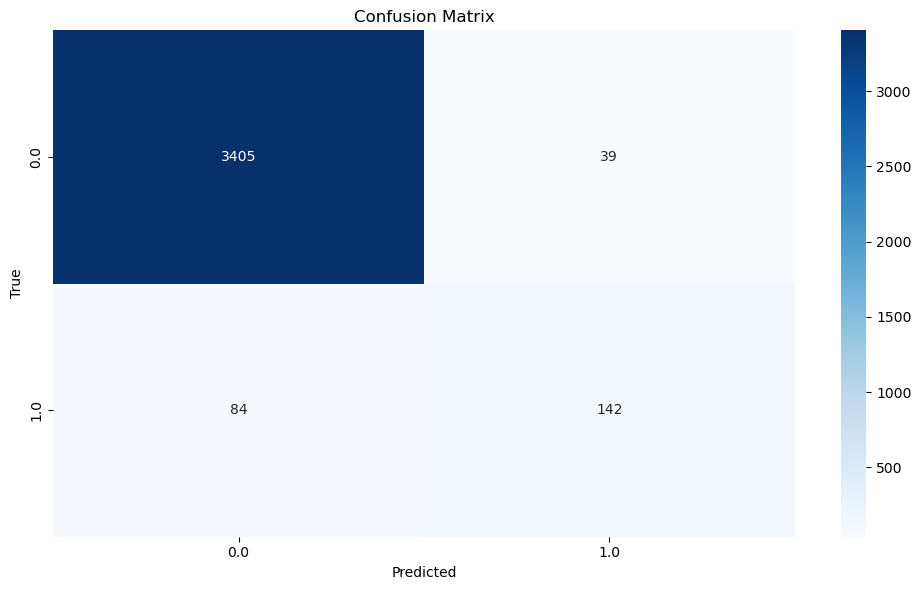

Scores: {'accuracy': 0.9664850136239782, 'f1': 0.964740987342053, 'weightedPrecision': 0.9641382213597868, 'weightedRecall': 0.9664850136239782, 'macroF1': np.float64(0.8400237301145999)}
Labels: [0.0, 1.0]
Confusion matrix:
 [[3405   39]
 [  84  142]]


In [24]:
# Initialize the random forest classifier
rfc = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=50,
    maxDepth=10,
    maxBins=64,
    impurity="gini",
    featureSubsetStrategy="auto",
    seed=42
)

# Fit model
rf_model = rfc.fit(trainingVecDF)

# Evaluate on test set
predictions = rf_model.transform(testVecDF)

out = evaluate_metrics_visual(
    predictions,
    labelCol="label",
    predictionCol="prediction",
    metrics=["accuracy", "f1", "weightedPrecision", "weightedRecall"]
)

# Inspect results
print("Scores:", out["scores"])
print("Labels:", out["labels"])
print("Confusion matrix:\n", out["confusion_matrix"])


### 5. Neural Network Model

Input Size: 31
accuracy: 0.960490
f1: 0.960367
weightedPrecision: 0.960248
weightedRecall: 0.960490
macroF1: 0.828009


C:\Users\rfaber\AppData\Local\Temp\ipykernel_15292\1195369403.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric_vals, y=metric_names, palette="viridis")


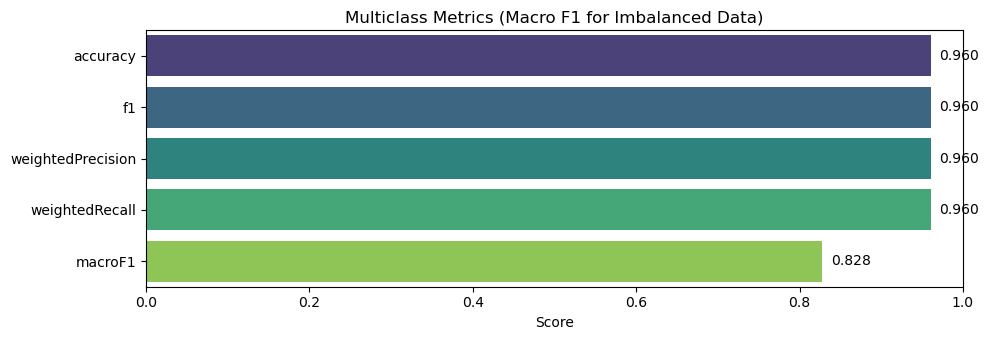

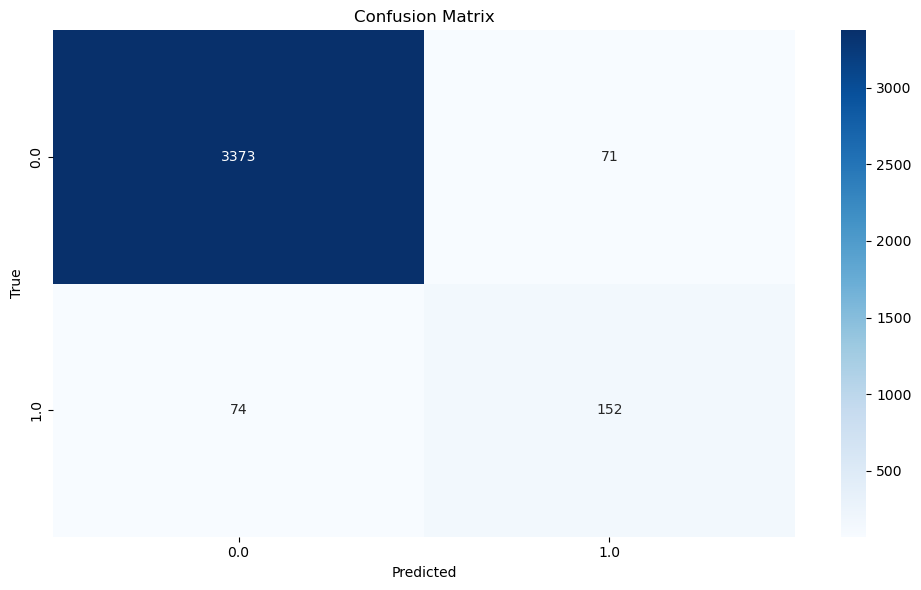

Scores: {'accuracy': 0.9604904632152589, 'f1': 0.9603670716917129, 'weightedPrecision': 0.9602477511931183, 'weightedRecall': 0.9604904632152589, 'macroF1': np.float64(0.8280090974347936)}
Labels: [0.0, 1.0]
Confusion matrix:
 [[3373   71]
 [  74  152]]


In [25]:
# Set input_size of the NN as the amount of features
input_size = trainingVecDF.select("features").first()["features"].size
output_size = 2  # binary: No Ballot / Ballot
print(f"Input Size: {input_size}")

layers = [input_size, 24, 12, 8, output_size] 

# Create the MLP Classifier
mlp = MultilayerPerceptronClassifier(
    featuresCol="features",
    labelCol="label",
    layers=layers,
    maxIter=250,     
    blockSize=64,     
    stepSize=0.03,    
    seed=42
)

# Fit the model
mlp_model = mlp.fit(trainingVecDF)

# Evaluate on test set
mlp_predictions = mlp_model.transform(testVecDF)

out = evaluate_metrics_visual(mlp_predictions,
                              labelCol="label",
                              predictionCol="prediction",
                              metrics=["accuracy","f1","weightedPrecision","weightedRecall"])

# inspect results
print("Scores:", out["scores"])
print("Labels:", out["labels"])
print("Confusion matrix:\n", out["confusion_matrix"])

## Hyperparameter fine-tuned Models

### 1. Decision-tree grid-search

DECISION TREE RESULTS:
Best Impurity: entropy
Best Max Depth: 10
Best Min Instances: 1
accuracy: 0.959673
f1: 0.958230
weightedPrecision: 0.957292
weightedRecall: 0.959673
macroF1: 0.813116


C:\Users\rfaber\AppData\Local\Temp\ipykernel_15292\1195369403.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric_vals, y=metric_names, palette="viridis")


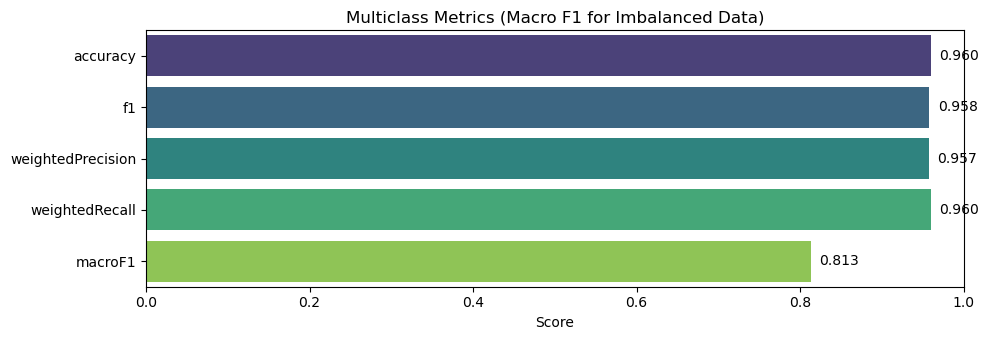

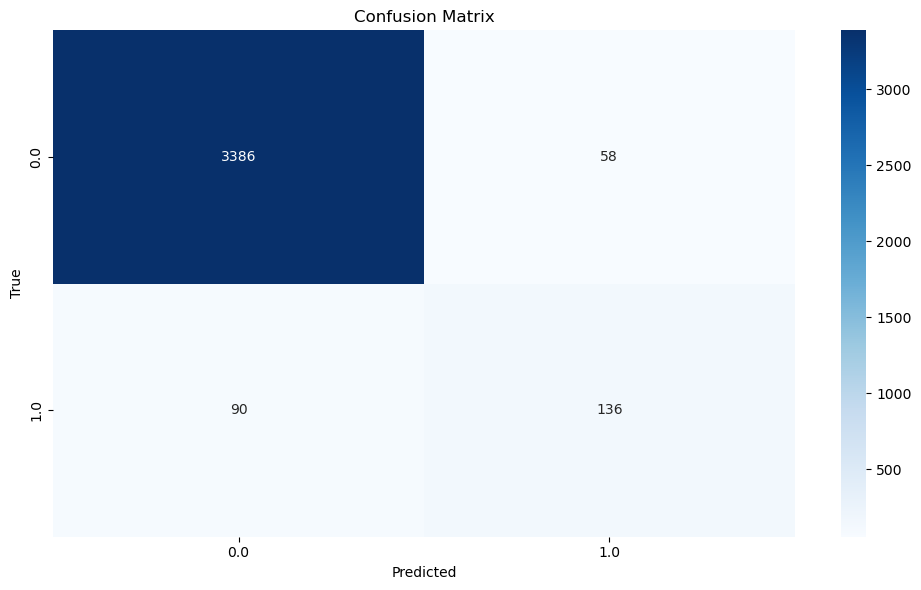

Scores: {'accuracy': 0.9596730245231607, 'f1': 0.958230000352506, 'weightedPrecision': 0.9572919695478963, 'weightedRecall': 0.9596730245231607, 'macroF1': np.float64(0.8131158821910267)}
Labels: [0.0, 1.0]
Confusion matrix:
 [[3386   58]
 [  90  136]]


In [ ]:
# Create the DTC Classifier
dtc = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    seed=42
)

# Hyperparameter grid
# Try to find best depth, impurity measurement and minInstancesperNode
grid = (ParamGridBuilder()
    .addGrid(dtc.impurity, ["gini", "entropy"]) 
    .addGrid(dtc.maxDepth, [5, 7, 10])
    .addGrid(dtc.minInstancesPerNode, [1, 5, 10])
    .build())

# Create Cross Validator
cv = CrossValidator(
    estimator=dtc,
    estimatorParamMaps=grid,
    evaluator=MulticlassClassificationEvaluator(labelCol="label", metricName="f1"),,
    numFolds=3,
    seed=42
)

dt_model = cv.fit(trainingVecDF)

# Extract best model
best_dt = dt_model.bestModel
dt_predictions = best_dt.transform(testVecDF)

print("DECISION TREE RESULTS:")
print(f"Best Impurity: {best_dt.getImpurity()}")
print(f"Best Max Depth: {best_dt.getMaxDepth()}")
print(f"Best Min Instances: {best_dt.getMinInstancesPerNode()}")

# Evaluate on test set
out = evaluate_metrics_visual(dt_predictions,
                              labelCol="label",
                              predictionCol="prediction",
                              metrics=["accuracy","f1","weightedPrecision","weightedRecall"])

# inspect results
print("Scores:", out["scores"])
print("Labels:", out["labels"])
print("Confusion matrix:\n", out["confusion_matrix"])

### 2. Random Forest grid-search

accuracy: 0.967847
f1: 0.965964
weightedPrecision: 0.965543
weightedRecall: 0.967847
macroF1: 0.844730


C:\Users\rfaber\AppData\Local\Temp\ipykernel_15292\1195369403.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric_vals, y=metric_names, palette="viridis")


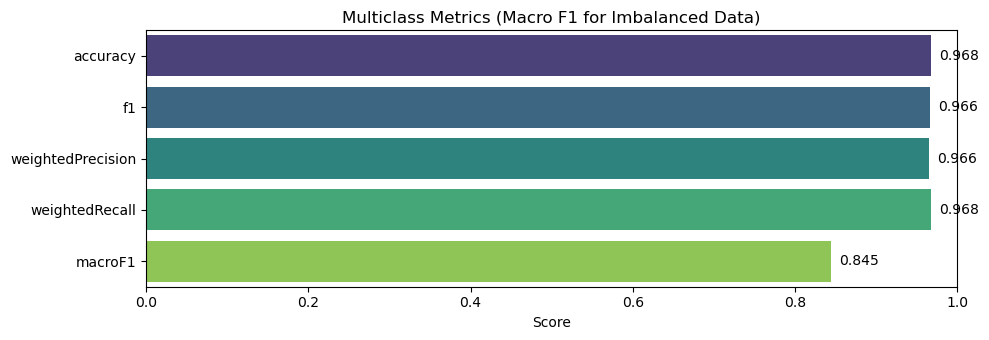

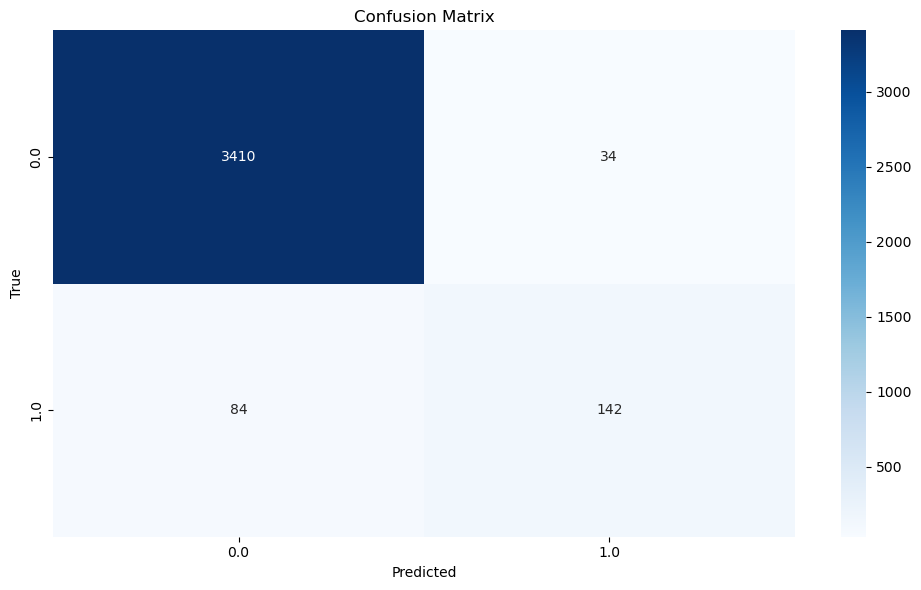

Scores: {'accuracy': 0.9678474114441417, 'f1': 0.96596372918879, 'weightedPrecision': 0.9655430435330661, 'weightedRecall': 0.9678474114441417, 'macroF1': np.float64(0.8447299392343557)}
Labels: [0.0, 1.0]
Confusion matrix:
 [[3410   34]
 [  84  142]]


In [ ]:
# Create the RFC
rfc = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=50,        
    maxDepth=10,
    maxBins=64,
    impurity="gini",
    featureSubsetStrategy="auto",
    seed=42
)

# Evaluator
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

# Gridsearch with number of Trees and maxDepth
grid = ParamGridBuilder() \
    .addGrid(rfc.numTrees, [50, 100, 200]) \
    .addGrid(rfc.maxDepth, [5, 10, 15]) \
    .build()

# CrossValidator
cv = CrossValidator(
    estimator=rfc,
    estimatorParamMaps=grid,
    evaluator=MulticlassClassificationEvaluator(labelCol="label", metricName="f1"),,
    numFolds=3
)

# Fit model
rf_model = cv.fit(trainingVecDF)

# Evaluate on test set
predictions = rf_model.bestModel.transform(testVecDF)

out = evaluate_metrics_visual(predictions,
                              labelCol="label",
                              predictionCol="prediction",
                              metrics=["accuracy","f1","weightedPrecision","weightedRecall"])
# inspect results
print("Scores:", out["scores"])
print("Labels:", out["labels"])
print("Confusion matrix:\n", out["confusion_matrix"])


### 3. Neural Network grid-search

Input Size: 31
Running Grid Search Cross-Validation...
MLP GRID SEARCH RESULTS:
Best Layers: [31, 48, 24, 12, 2]
Best MaxIter: 100
accuracy: 0.963215
f1: 0.961854
weightedPrecision: 0.961056
weightedRecall: 0.963215
macroF1: 0.829149


C:\Users\rfaber\AppData\Local\Temp\ipykernel_15292\1195369403.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric_vals, y=metric_names, palette="viridis")


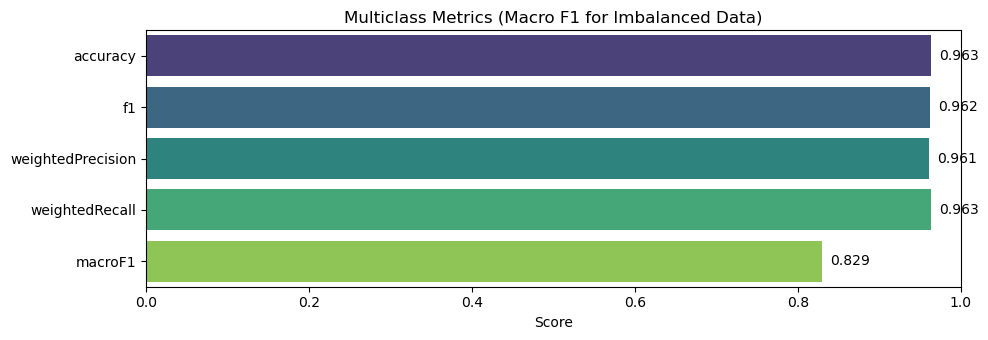

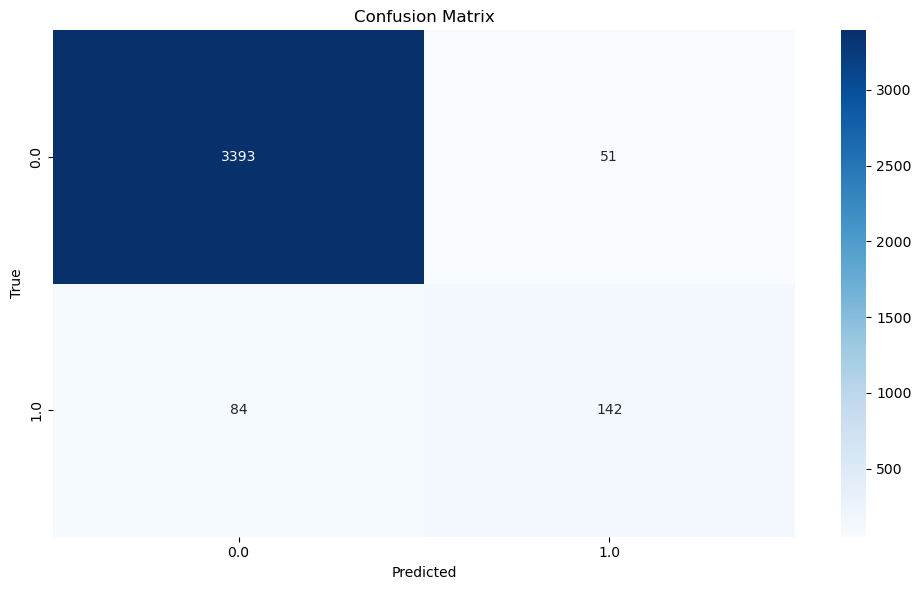

Scores: {'accuracy': 0.9632152588555858, 'f1': 0.961854391672213, 'weightedPrecision': 0.9610564119196869, 'weightedRecall': 0.9632152588555859, 'macroF1': np.float64(0.8291492220935971)}
Labels: [0.0, 1.0]
Confusion matrix:
 [[3393   51]
 [  84  142]]


In [ ]:
# Set input_size of the NN as the amount of features
input_size = trainingVecDF.select("features").first()["features"].size
output_size = 2  # binary: No Ballot / Ballot
print(f"Input Size: {input_size}")

# Initialize the MLP classifier
mlp = MultilayerPerceptronClassifier(
    featuresCol="features",
    labelCol="label",
    blockSize=64,
    seed=42
)

# Setup the Parameter Grid
# adjust layers, max Iterations and step size
paramGrid = (ParamGridBuilder()
    .addGrid(mlp.layers, [
        [input_size, 24, 12, 8, output_size],  
        [input_size, 32, 16, output_size],      
        [input_size, 48, 24, 12, output_size]   
    ])
    .addGrid(mlp.maxIter, [100, 250])
    .addGrid(mlp.stepSize, [0.03, 0.01])
    .build())

# Setup CrossValidator
cv = CrossValidator(
    estimator=mlp,
    estimatorParamMaps=paramGrid,
    evaluator=MulticlassClassificationEvaluator(labelCol="label", metricName="f1"),,
    numFolds=3,
    seed=42
)

# Fit the CrossValidator
print("Running Grid Search Cross-Validation...")
cv_model = cv.fit(trainingVecDF)

# Extract the best model from the grid search
mlp_model = cv_model.bestModel
mlp_predictions = mlp_model.transform(testVecDF)

print("MLP GRID SEARCH RESULTS:")
print(f"Best Layers: {mlp_model.getLayers()}")
print(f"Best MaxIter: {mlp_model.getMaxIter()}")

# run with predictions
out = evaluate_metrics_visual(mlp_predictions,
                              labelCol="label",
                              predictionCol="prediction",
                              metrics=["accuracy","f1","weightedPrecision","weightedRecall"])

# inspect results
print("Scores:", out["scores"])
print("Labels:", out["labels"])
print("Confusion matrix:\n", out["confusion_matrix"])

### 4. Gradient-Boosting grid-search

In [ ]:
# Initialize base classifier
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    seed=42
)

# Setup the Parameter Grid
paramGrid = (ParamGridBuilder()
    .addGrid(gbt.maxIter, [20, 50, 100])
    .addGrid(gbt.maxDepth, [3, 5, 7])
    .addGrid(gbt.stepSize, [0.1, 0.05])
    .build())

# Setup CrossValidator
cv = CrossValidator(
    estimator=gbt,
    estimatorParamMaps=paramGrid,
    evaluator=MulticlassClassificationEvaluator(labelCol="label", metricName="f1"),,
    numFolds=3,
    seed=42
)

# Fit the CrossValidator
cv_model = cv.fit(trainingVecDF)

# Extract best model
best_gbt_model = cv_model.bestModel
gbt_predictions = best_gbt_model.transform(testVecDF)

print("GBT GRID SEARCH RESULTS:")
print(f"Best MaxIter: {best_gbt_model.getMaxIter()}")
print(f"Best MaxDepth: {best_gbt_model.getMaxDepth()}")

# run with predictions
out = evaluate_metrics_visual(gbt_predictions,
                              labelCol="label",
                              predictionCol="prediction",
                              metrics=["accuracy","f1","weightedPrecision","weightedRecall"])

# inspect results
print("Scores:", out["scores"])
print("Labels:", out["labels"])
print("Confusion matrix:\n", out["confusion_matrix"])